# Análisis exploratorio de Datos


In [60]:
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:_.2f}'.format


df = pd.read_csv("../datos/df_clean.csv", parse_dates=["fecha_publicacion", "fecha_firma_contrato"])

print(df.shape)
print(df.dtypes)

(25451, 29)
id                                      str
planificacion_id                        str
convocatoria_id                         str
id_llamado                            int64
nombre_licitacion                       str
convocante                              str
categoria_id                          int64
categoria_codigo                      int64
categoria                               str
tipo_procedimiento_id                 int64
tipo_procedimiento_codigo               str
tipo_procedimiento                      str
_estado                                 str
estado                                  str
_sistema_adjudicacion                   str
sistema_adjudicacion                    str
monto_total_adjudicado              float64
monto_periodo                       float64
_moneda                                 str
moneda                                  str
fecha_publicacion            datetime64[us]
restricciones                           str
url                 

In [61]:
print(df['moneda'].value_counts())

moneda
Guaraníes    25360
Dólares         91
Name: count, dtype: int64


In [62]:
df = df[df["moneda"] == "Guaraníes"].copy()
print(df.shape)

(25360, 29)


In [63]:
print(df["fecha_publicacion"].dt.year.value_counts().sort_index())

fecha_publicacion
2021    12362
2022    12998
Name: count, dtype: int64


primera pregunta: 
Como se distribuyen las contrataciones ?

In [64]:
print(df["tipo_procedimiento"].value_counts())

tipo_procedimiento
Contratación Directa                                                                                11899
Licitación Pública Nacional                                                                          5611
Concurso de Ofertas                                                                                  4877
Contratación por Excepción                                                                           1413
Locación de Inmuebles                                                                                 936
BID - Concurso de Ofertas (CO/CP)                                                                     150
Licitación Pública Internacional                                                                       94
Acuerdo Nacional                                                                                       66
BID - Licitación Internacional                                                                         36
Selección basada en la cali

In [65]:
# Agrupar procedimientos con menos de 200 registros en "Otros"
top_proc = df["tipo_procedimiento"].value_counts()
df["tipo_proc_agrupado"] = df["tipo_procedimiento"].where(
    df["tipo_procedimiento"].isin(top_proc[top_proc >= 200].index),
    other="Otros"
)

print(df["tipo_proc_agrupado"].value_counts())

tipo_proc_agrupado
Contratación Directa           11899
Licitación Pública Nacional     5611
Concurso de Ofertas             4877
Contratación por Excepción      1413
Locación de Inmuebles            936
Otros                            624
Name: count, dtype: int64


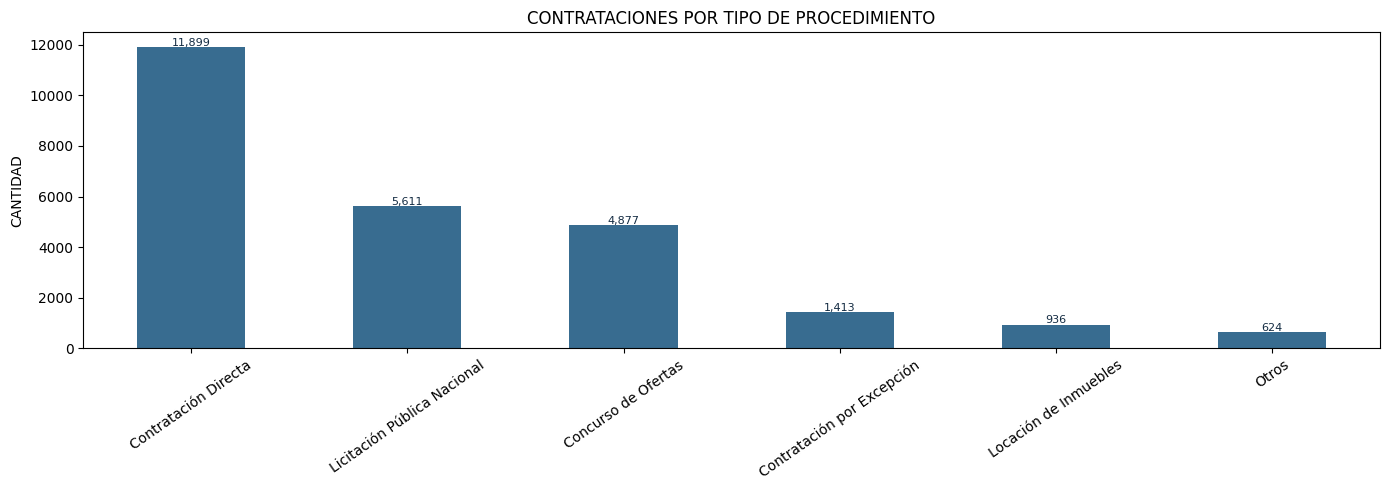

In [66]:
fig, ax = plt.subplots(figsize=(14, 5))

conteos = df["tipo_proc_agrupado"].value_counts()

conteos.plot(kind="bar", ax=ax, color="#386c90", edgecolor="none")
ax.set_title("CONTRATACIONES POR TIPO DE PROCEDIMIENTO")
ax.set_xlabel("")
ax.set_ylabel("CANTIDAD")
ax.tick_params(axis="x", rotation=35)

# Etiquetas encima de cada barra
for i, v in enumerate(conteos):
    ax.text(i, v + 50, f"{v:,}", ha="center", fontsize=8, color="#132b42")

plt.tight_layout()
plt.savefig("../figs/fig01_tipo_procedimiento.png", dpi=150, bbox_inches="tight")
plt.show()

In [67]:
print(df["convocante"].nunique())
print(df["convocante"].value_counts().head(20))

408
convocante
Ministerio de Salud Pública y Bienestar Social / Poder Ejecutivo                              2246
Instituto de Previsión Social / Entidades Públicas de Seguridad Social                        1034
Administración Nacional de Electricidad / Empresas Públicas                                    610
Policia Nacional / Ministerio del Interior / Poder Ejecutivo                                   585
Facultad de Ciencias Medicas / Universidad Nacional de Asunción / Universidades Nacionales     462
Tribunal Superior de Justicia Electoral / Poder Judicial                                       439
Ministerio de Agricultura y Ganadería / Poder Ejecutivo                                        307
Industria Nacional del Cemento / Empresas Públicas                                             290
Servicio Nacional de Calidad y Salud Animal / Entes Autónomos y Autárquicos                    284
Petróleos Paraguayos / Empresas Públicas                                                      

In [68]:
# Extraer solo el primer nivel — nombre de la institución
df["convocante_limpio"] = df["convocante"].str.split("/").str[0].str.strip()

print(df["convocante_limpio"].value_counts().head(10))

convocante_limpio
Ministerio de Salud Pública y Bienestar Social    2246
Instituto de Previsión Social                     1034
Administración Nacional de Electricidad            610
Policia Nacional                                   585
Facultad de Ciencias Medicas                       462
Tribunal Superior de Justicia Electoral            439
Ministerio de Agricultura y Ganadería              307
Industria Nacional del Cemento                     290
Servicio Nacional de Calidad y Salud Animal        284
Petróleos Paraguayos                               283
Name: count, dtype: int64


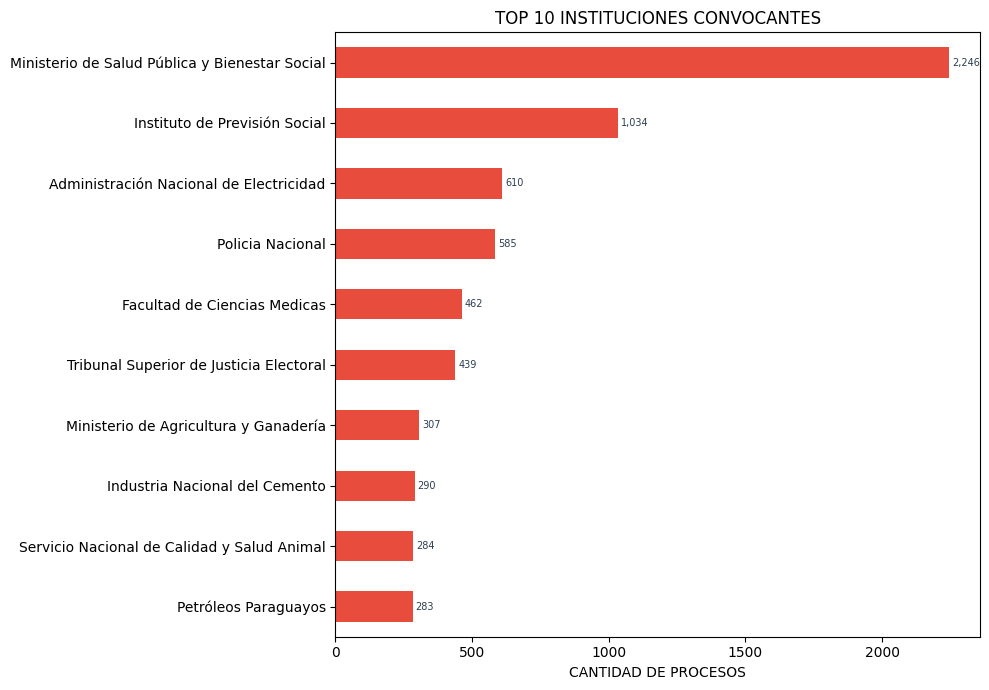

In [69]:
top10 = df["convocante_limpio"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 7))

top10.sort_values().plot(kind="barh", ax=ax, color="#e74c3c", edgecolor="none")

ax.set_title("TOP 10 INSTITUCIONES CONVOCANTES")
ax.set_xlabel("CANTIDAD DE PROCESOS")
ax.set_ylabel("")

# Etiquetas al final de cada barra
for i, v in enumerate(top10.sort_values()):
    ax.text(v + 10, i, f"{v:,}", va="center", fontsize=7, color="#2c3e50")

plt.tight_layout()
plt.savefig("../figs/fig02_top10_convocantes.png", dpi=150, bbox_inches="tight")
plt.show()

In [70]:
print(df.groupby("tipo_proc_agrupado")["monto_total_adjudicado"].describe())

                                count              mean                std  \
tipo_proc_agrupado                                                           
Concurso de Ofertas          4_877.00    407_403_247.62     207_234_928.78   
Contratación Directa        11_899.00     82_708_602.68      55_407_062.90   
Contratación por Excepción   1_413.00 10_205_527_503.98  19_290_458_839.96   
Licitación Pública Nacional  5_611.00 44_409_842_901.32 112_564_149_156.34   
Locación de Inmuebles          936.00  1_259_191_660.77   1_651_582_260.63   
Otros                          624.00 37_702_112_573.03 115_946_465_545.53   

                                      min              25%              50%  \
tipo_proc_agrupado                                                            
Concurso de Ofertas          1_200_000.00   240_000_000.00   359_158_070.00   
Contratación Directa           124_950.00    32_389_875.00    75_000_000.00   
Contratación por Excepción   3_100_000.00   169_709_000.00 

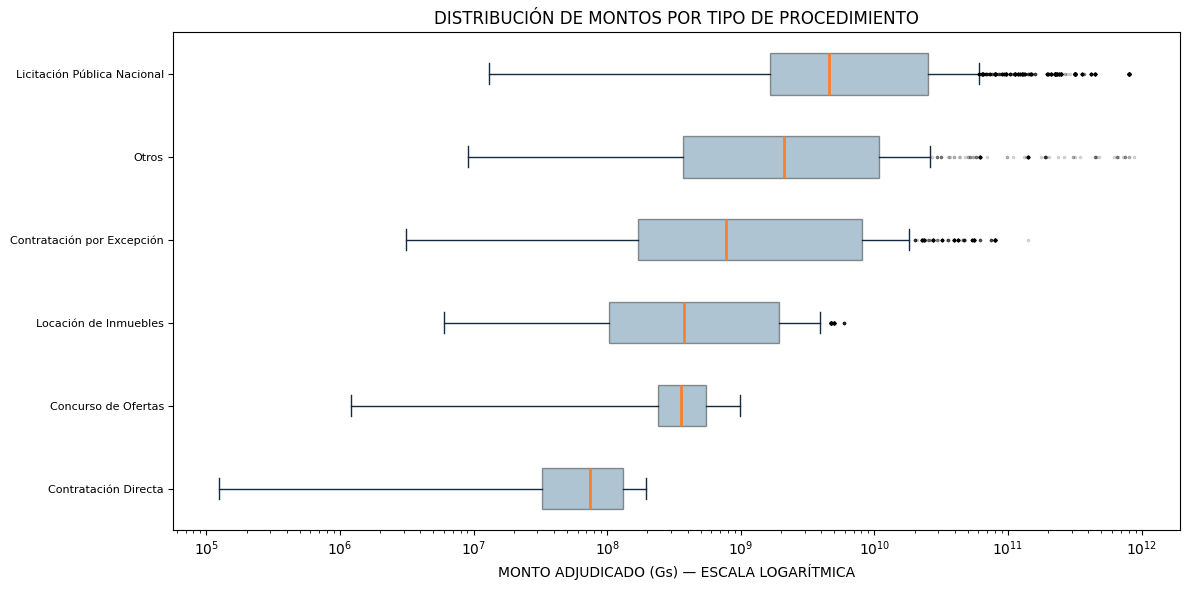

In [71]:
# boxplot con escala logaritmica 

fig, ax = plt.subplots(figsize=(12, 6))

orden = df.groupby("tipo_proc_agrupado")["monto_total_adjudicado"].median().sort_values().index

data = [df[df["tipo_proc_agrupado"] == cat]["monto_total_adjudicado"].values 
        for cat in orden]

bp = ax.boxplot(data, vert=False, patch_artist=True,
                medianprops=dict(color="#FA802A", linewidth=2),
                boxprops=dict(facecolor="#386c90", alpha=0.4),
                whiskerprops=dict(color="#132b42"),
                capprops=dict(color="#132b42"),
                flierprops=dict(marker=".", color="#132b42", alpha=0.2, markersize=3))

ax.set_yticks(range(1, len(orden) + 1))
ax.set_yticklabels(orden, fontsize=8)
ax.set_xscale("log")
ax.set_title("DISTRIBUCIÓN DE MONTOS POR TIPO DE PROCEDIMIENTO")
ax.set_xlabel("MONTO ADJUDICADO (Gs) — ESCALA LOGARÍTMICA")

plt.tight_layout()
plt.savefig("../figs/fig03_montos_tipo_procedimiento.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribución de montos por tipo de procedimiento

El gráfico usa escala logarítmica porque las distribuciones son fuertemente 
sesgadas — unos pocos contratos de valor extremo distorsionan cualquier 
visualización en escala lineal.

**Lecturas clave:**

- **Contratación Directa** es el procedimiento más frecuente (47% de los procesos) 
  pero opera en rangos de monto bajos y consistentes — mediana ~75M Gs. 
  Es el mecanismo cotidiano del Estado para compras menores.

- **Licitación Pública Nacional** concentra los contratos de mayor valor — 
  mediana ~4.500M Gs, con casos que superan los 800.000M. Es el procedimiento 
  diseñado para adquisiciones de alto impacto.

- **Contratación por Excepción** presenta la dispersión más alta en relación 
  a su volumen. Montos que van desde 3M hasta 142.000M en un procedimiento 
  que por definición evita la competencia — señal que merece atención en 
  análisis de transparencia.

- **Locación de Inmuebles** tiene la distribución más compacta — lógico, 
  los alquileres del Estado operan en rangos relativamente predecibles.

> *Nota metodológica: los montos están expresados en guaraníes. 
> No se aplicó ajuste por inflación dado que el período analizado es 
> relativamente corto (2021–2022).*

## ¿Cómo varía el monto por categoría?

In [72]:
print(df.groupby("categoria")["monto_total_adjudicado"].median().sort_values(ascending=False).head(15))
print()
print(df["categoria"].value_counts().head(15))

categoria
Capacitaciones y Adiestramientos                                                                                    12_504_916_600.00
Equipos, Productos e instrumentales Médicos y de Laboratorio. Servicios asistenciales de salud                       4_739_140_490.00
Productos Alimenticios                                                                                                 729_062_793.00
Equipos Militares y de Seguridad. Servicio de Seguridad y Vigilancia                                                   500_000_000.00
Servicios de ceremonial, gastronomico y funerarios                                                                     340_220_960.00
Adquisición y Locación de inmuebles. Alquiler de muebles                                                               316_500_000.00
Bienes e insumos agropecuario y forestal                                                                               247_946_025.00
Maquinarias, Equipos y herramientas mayores - Equipo

In [73]:
# Abreviar nombres de categoría
abrev = {
    "Construcción, Restauración, Reconstrucción o Remodelación y Reparación de Inmuebles": "Construcción",
    "Equipos, Productos e instrumentales Médicos y de Laboratorio. Servicios asistenciales de salud": "Equipos Médicos",
    "Servicios de Limpiezas, Mantenimientos y reparaciones menores y mayores de Instalaciones, Maquinarias y Vehículos": "Limpieza y Mantenimiento",
    "Equipos, accesorios y programas computacionales, de oficina, educativos, de imprenta, de comunicación y señalamiento": "Equipos TI y Oficina",
    "Materiales e insumos eléctricos, metálicos y no metálicos, Plásticos, cauchos. Repuestos, herramientas, cámaras y cubiertas.": "Materiales e Insumos",
    "Utiles de oficina, Productos de papel y cartón e impresos": "Útiles de Oficina",
    "Adquisición y Locación de inmuebles. Alquiler de muebles": "Inmuebles",
    "Maquinarias, Equipos y herramientas mayores - Equipos de transporte": "Maquinarias y Transporte",
    "Consultorías, Asesorías e Investigaciones. Estudios y Proyectos de inversión": "Consultorías",
    "Servicios de ceremonial, gastronomico y funerarios": "Servicios Ceremoniales",
}

df["categoria_corta"] = df["categoria"].replace(abrev)
df["categoria_corta"] = df["categoria_corta"].apply(lambda x: x[:35] + "..." if len(x) > 35 else x)

print(df["categoria_corta"].value_counts().head(15))

categoria_corta
Construcción                4174
Equipos Médicos             3740
Limpieza y Mantenimiento    2635
Equipos TI y Oficina        2481
Materiales e Insumos        1745
Útiles de Oficina           1459
Servicios Técnicos          1240
Inmuebles                   1163
Productos Alimenticios       889
Muebles y Enseres            861
Maquinarias y Transporte     850
Consultorías                 755
Servicios Ceremoniales       578
Productos quimicos           497
Seguros                      479
Name: count, dtype: int64


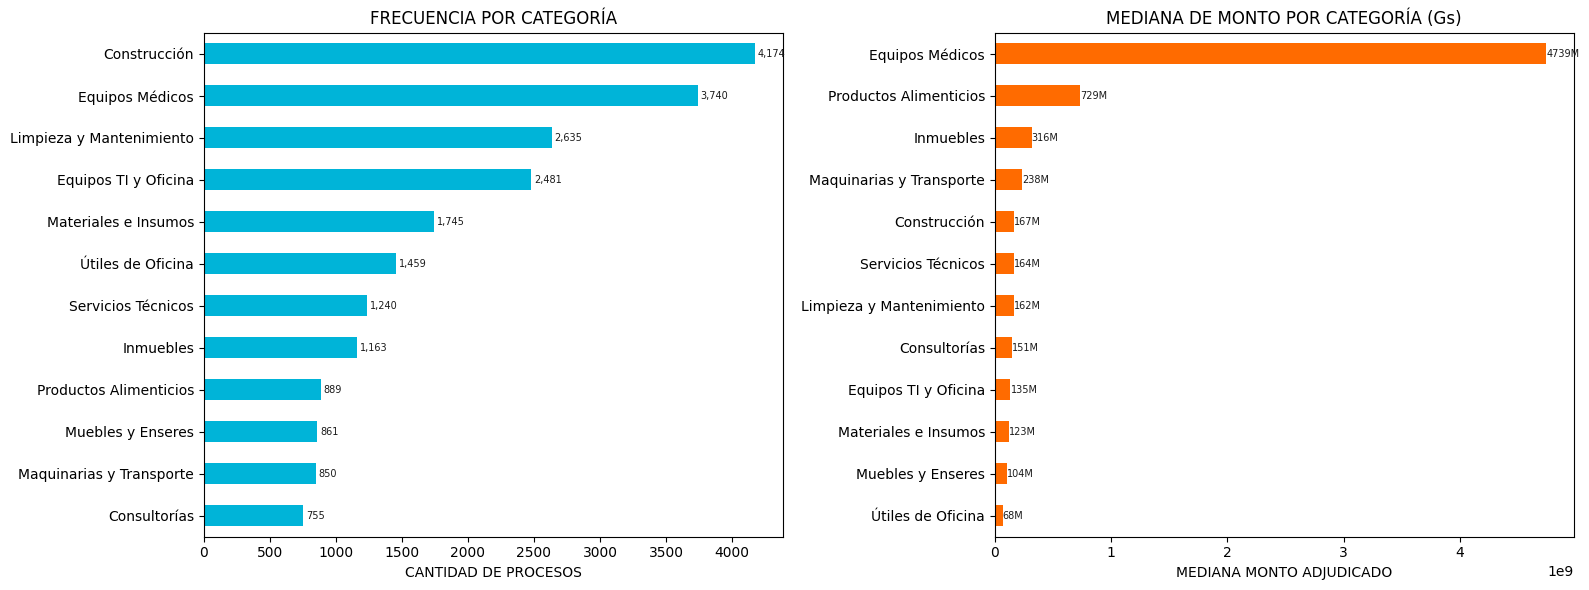

In [74]:
top_cat = df["categoria_corta"].value_counts().head(12).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo — frecuencia
conteos = df["categoria_corta"].value_counts().head(12).sort_values()
conteos.plot(kind="barh", ax=axes[0], color="#00B4D8", edgecolor="none")
axes[0].set_title("FRECUENCIA POR CATEGORÍA")
axes[0].set_xlabel("CANTIDAD DE PROCESOS")
axes[0].set_ylabel("")
for i, v in enumerate(conteos):
    axes[0].text(v + 20, i, f"{v:,}", va="center", fontsize=7, color="#1A1A1A")

# Panel derecho — mediana de monto
medianas = (df[df["categoria_corta"].isin(top_cat)]
            .groupby("categoria_corta")["monto_total_adjudicado"]
            .median()
            .sort_values())
medianas.plot(kind="barh", ax=axes[1], color="#FF6B00", edgecolor="none")
axes[1].set_title("MEDIANA DE MONTO POR CATEGORÍA (Gs)")
axes[1].set_xlabel("MEDIANA MONTO ADJUDICADO")
axes[1].set_ylabel("")
for i, v in enumerate(medianas):
    axes[1].text(v + 1e6, i, f"{v/1e6:.0f}M", va="center", fontsize=7, color="#1A1A1A")

plt.tight_layout()
plt.savefig("../figs/fig04_categorias.png", dpi=150, bbox_inches="tight")
plt.show()

## Distribución por categoría de contratación

Se analizan las 12 categorías más frecuentes del dataset. Los dos paneles 
muestran dimensiones distintas — frecuencia y valor — que no necesariamente 
coinciden.

**Lecturas clave:**

- **Construcción** y **Equipos Médicos** lideran en frecuencia. El Estado 
  paraguayo destina una proporción significativa de sus procesos de compra 
  a infraestructura y salud.

- **Equipos Médicos** presenta la mediana de monto más alta entre las 
  categorías frecuentes — contratos de alto valor y alta recurrencia 
  simultáneamente. Categoría de alto impacto presupuestario.

- **Útiles de Oficina** y **Muebles y Enseres** aparecen con frecuencia 
  relevante pero montos bajos — compras rutinarias y de bajo valor unitario.

- La brecha entre frecuencia y monto revela que el volumen de procesos 
  no es un proxy confiable del volumen presupuestario. Un análisis de 
  transparencia debe considerar ambas dimensiones simultáneamente.

> *Se utilizó la mediana en lugar de la media para reducir el efecto 
> de contratos atípicos de valor extremo presentes en todas las categorías.*

In [75]:
print(df.groupby(df["fecha_publicacion"].dt.to_period("M")).size())

fecha_publicacion
2021-01     166
2021-02     443
2021-03     706
2021-04     787
2021-05     944
2021-06    1075
2021-07    1220
2021-08    1211
2021-09    1134
2021-10    1312
2021-11    2480
2021-12     884
2022-01     111
2022-02     285
2022-03     680
2022-04     883
2022-05    1020
2022-06    1198
2022-07    1105
2022-08    1213
2022-09    1305
2022-10    1348
2022-11    3198
2022-12     652
Freq: M, dtype: int64


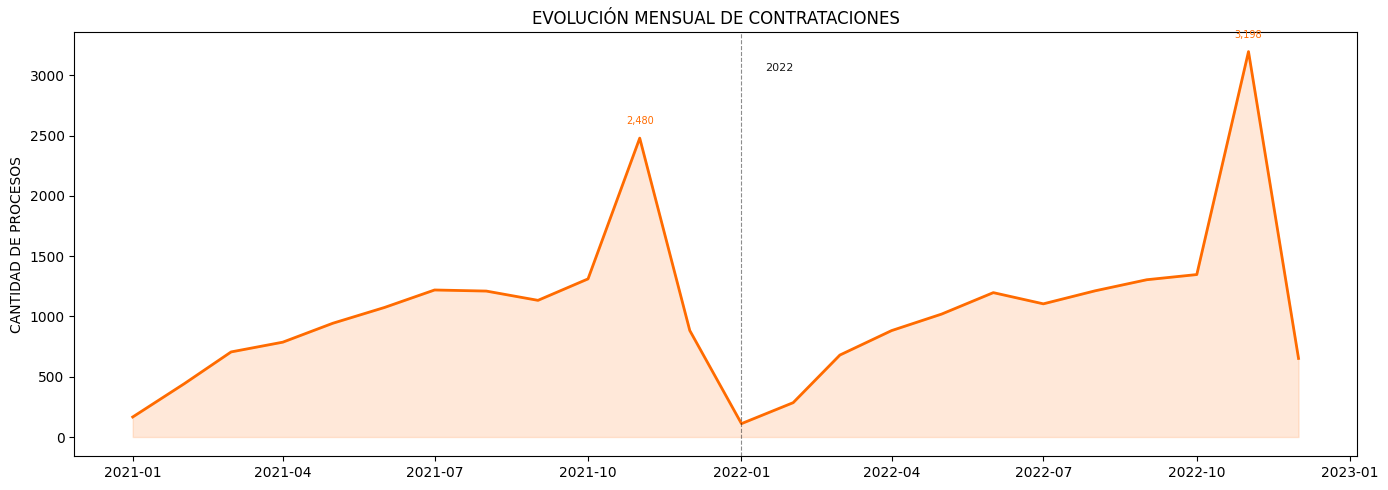

In [76]:
serie = df.groupby(df["fecha_publicacion"].dt.to_period("M")).size()
serie.index = serie.index.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(serie.index, serie.values, color="#FF6B00", linewidth=2)
ax.fill_between(serie.index, serie.values, alpha=0.15, color="#FF6B00")

# Marcar picos de noviembre
for fecha, val in serie.items():
    if fecha.month == 11:
        ax.annotate(f"{val:,}", xy=(fecha, val),
                    xytext=(0, 10), textcoords="offset points",
                    ha="center", fontsize=7, color="#FF6B00")

ax.set_title("EVOLUCIÓN MENSUAL DE CONTRATACIONES")
ax.set_xlabel("")
ax.set_ylabel("CANTIDAD DE PROCESOS")
ax.axvline(pd.Timestamp("2022-01-01"), color="#1A1A1A", linewidth=0.8, linestyle="--", alpha=0.5)
ax.text(pd.Timestamp("2022-01-15"), serie.max() * 0.95, "2022", fontsize=8, color="#1A1A1A")

plt.tight_layout()
plt.savefig("../figs/fig05_evolucion_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

## Evolución mensual de contrataciones (2021–2022)

El volumen de procesos sigue un patrón estacional consistente en ambos años,
revelando la lógica del ciclo presupuestario del Estado paraguayo.

**Lecturas clave:**

- **Noviembre es el mes pico** en ambos años — 2.480 procesos en 2021 y 
  3.198 en 2022. Las instituciones concentran sus contrataciones en el 
  último trimestre para ejecutar el presupuesto antes del cierre del 
  ejercicio fiscal.

- **Enero cae drásticamente** — 166 procesos en 2021 y apenas 111 en 2022. 
  El inicio del ciclo presupuestario genera un vacío de actividad mientras 
  se aprueban y distribuyen los nuevos presupuestos institucionales.

- **El crecimiento interanual es visible** — 2022 supera consistentemente 
  a 2021 en los meses centrales del año, sugiriendo mayor actividad 
  contractual o mayor registro en el portal.

- El patrón de acumulación de fin de año es una señal de alerta desde 
  la perspectiva de transparencia — las contrataciones apresuradas en 
  noviembre tienen menor tiempo de revisión y control.



In [77]:
# Guardar el DataFrame procesado para futuras etapas
df.to_csv("../datos/df_eda.csv", index=False)
print(df.shape)

(25360, 32)
